In [79]:
import math
import numpy as np
from scipy.stats import chi2
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

Part 1

In [80]:
rng = np.random.default_rng(30)

m = 10
s = 8
lbd = 1

def poisson_analytical(m, s, lbd):
    '''
    s is the mean number of services per unit of time
    lbd is the mean time between arrivals
    m is the number of servers
    '''

    A = s*lbd
    probas = np.array([A**i / math.factorial(i) for i in range(m+1)])
    c = 1 / np.sum(probas)      # normalizing constant
    P = c * probas
    return P

poisson_analytical(m, s, lbd)


array([0.00041116, 0.00328931, 0.01315724, 0.03508597, 0.07017194,
       0.1122751 , 0.14970014, 0.17108587, 0.17108587, 0.15207633,
       0.12166106])

In [81]:
rng = np.random.default_rng(30)

def metropolis_hastings(n ,burn_in, m, P, rng):
    '''
    n is the number of samples we want to simulate
    burn_in is the initial burn-in period we will discard
    '''
    
    samples = []
    sample = m // 2

    for t in range(n + burn_in):
        
        if sample == 0:         # lower bound (can only go forward)
            proposal = 1
        elif sample == m:       # upper bound (can only go backward)
            proposal = m-1
        else:                   # general case (can go in any direction)
            proposal = sample + rng.choice([-1, 1])
    
        alpha = min(1, P[proposal]/P[sample])       # probability of acceptance
        if rng.random() < alpha:
            sample = proposal
        if t > burn_in:                             # if burn-in time has passed, then keep the sample
            samples.append(sample)

    return np.array(samples)

Chi-square statistic = 0.030924361780367587
Degrees of freedom = 10
p-value = 0.9999999999927293


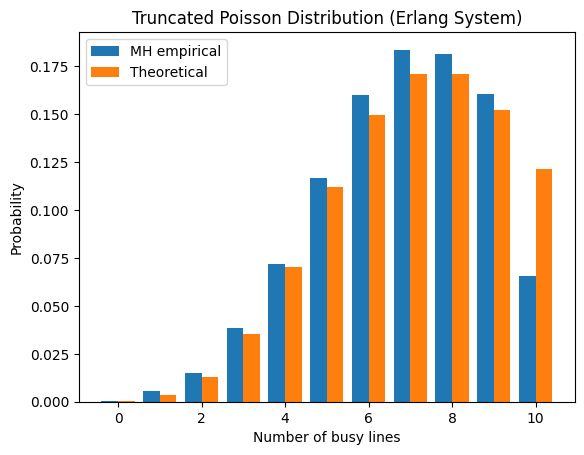

In [82]:
rng = np.random.default_rng(30)

n = 10000
burn_in = 1000
m = 10
s = 8
lbd = 1
P = poisson_analytical(m, s, lbd)
samples = metropolis_hastings(n, burn_in, m, P, rng)

# distribution
observed_counts = np.bincount(samples, minlength=m + 1)
observed_probas = observed_counts / n

# chi-square 
# expected_counts = n * P
chi2_stat = np.sum((observed_probas - P) ** 2 / P)
df = (m + 1) - 1
p_value = 1 - chi2.cdf(chi2_stat, df)

print("Chi-square statistic =", chi2_stat)
print("Degrees of freedom =", df)
print("p-value =", p_value)

x = np.arange(m + 1)
plt.bar(x - 0.2, observed_probas, width=0.4, label="MH empirical")
plt.bar(x + 0.2, P, width=0.4, label="Theoretical")
plt.xlabel("Number of busy lines")
plt.ylabel("Probability")
plt.title("Truncated Poisson Distribution (Erlang System)")
plt.legend()
plt.show()

Part 2

In [83]:
rng = np.random.default_rng(30)

m = 10
A1 = 4
A2 = 4

# def Pij(A1, A2):

#     probas = np.zeros((m+1, m+1))

#     i = rng.integers(0,m+1)
#     j = rng.integers(0,m+1)
#     while i+j > m:
#         i = rng.integers(m)
#         j = rng.integers(m)  

#     probas[i,j] = A1**i * A2**j / (math.factorial(i) * math.factorial(j))
    
#     c = 1 / np.sum(probas)      # normalizing constant
#     P = c * probas
#     return P

def Pij(A1, A2):

    probas = np.zeros((m+1, m+1))

    for i in range(m+1):
        for j in range(m+1):
            if i+j<=m:
                probas[i,j] = A1**i * A2**j / (math.factorial(i) * math.factorial(j))
    
    c = 1 / np.sum(probas)      # normalizing constant
    P = c * probas
    return P

# Pij(A1, A2)


In [84]:
rng = np.random.default_rng(30)

def metropolis_hastings_Pij(n, burn_in, m, P, rng):

    states = [(i, j) for i in range(m + 1) for j in range(m + 1) if i + j <= m]
    i, j = rng.choice(states)
    samples = []

    total_iters = n + burn_in

    for t in range(total_iters):

        proposal = rng.choice(["i+", "i-", "j+", "j-"])

        if proposal == "i+":
            new_i = i + 1
            new_j = j
        elif proposal == "i-":
            new_i = i - 1
            new_j = j
        elif proposal == "j+":
            new_i = i
            new_j = j + 1
        else:
            new_i = i
            new_j = j - 1

        while new_i<0 or new_j<0 or new_i+new_j>m:

            proposal = rng.choice(["i+", "i-", "j+", "j-"])
            
            if proposal == "i+":
                new_i = i + 1
                new_j = j
            elif proposal == "i-":
                new_i = i - 1
                new_j = j
            elif proposal == "j+":
                new_i = i
                new_j = j + 1
            else:
                new_i = i
                new_j = j - 1

        alpha = min(1.0, P[new_i, new_j] / P[i, j])
        if rng.random() < alpha:
            i, j = new_i, new_j
        if t >= burn_in:
            samples.append((i, j))

    return np.array(samples)

Chi-square statistic = 0.02163851968810464
Degrees of freedom = 35
p-value = 1.0


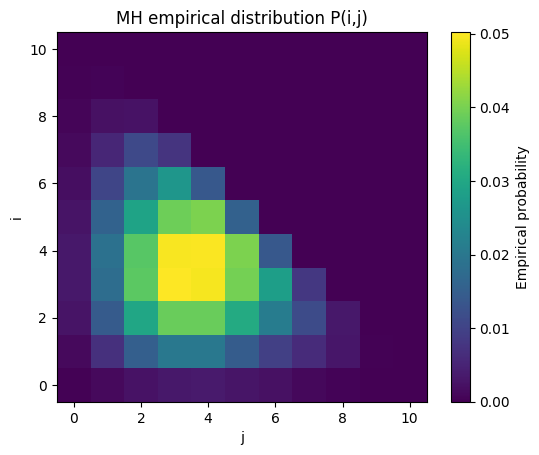

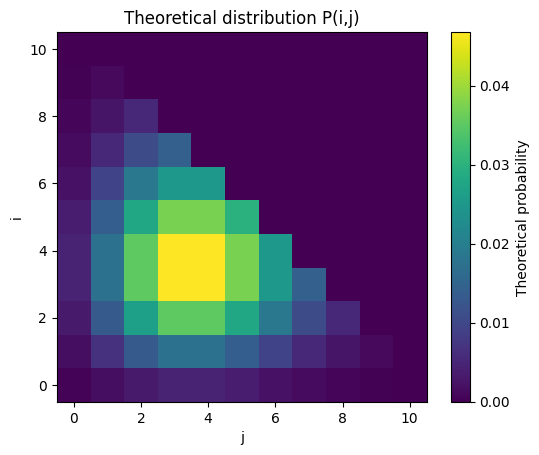

In [85]:
rng = np.random.default_rng(30)

n = 100000
burn_in = 5000
m = 10
A1 = 4
A2 = 4
P = Pij(A1, A2)

samples = metropolis_hastings_Pij(n, burn_in, m, P, rng)

observed_counts = np.zeros((m + 1, m + 1))
for i, j in samples:
    observed_counts[i, j] += 1
observed_probas = observed_counts / n

mask = np.triu(np.ones_like(P, dtype=bool))
emp = observed_probas[mask]
theo = P[mask]
valid = theo > 0

emp = emp[valid]
theo = theo[valid]

chi2_stat = np.sum((emp - theo) ** 2 / theo)
df = len(theo) - 1
p_value = 1 - chi2.cdf(chi2_stat, df)

print("Chi-square statistic =", chi2_stat)
print("Degrees of freedom =", df)
print("p-value =", p_value)

plt.imshow(observed_probas, origin="lower")
plt.colorbar(label="Empirical probability")
plt.title("MH empirical distribution P(i,j)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.imshow(P, origin="lower")
plt.colorbar(label="Theoretical probability")
plt.title("Theoretical distribution P(i,j)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()


Part 3